# Task1 — Linear Regression from Scratch (Enhanced)

## الفكرة الاساسية
الـ **Linear Regression** هو ابسط نموذج تعلم الي. هدفه انه يلاقي خط مستقيم يمثل العلاقة بين المدخلات `X` والمخرجات `y`.

المعادلة هي:
```
y = theta_0 + theta_1 * x
```
- `theta_0` = الـ intercept (نقطة قطع محور y)
- `theta_1` = الـ slope (الميل)

الهدف: ايجاد افضل قيم لـ theta بتقلل الخطا بين التوقعات والقيم الحقيقية.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Gradient Descent — ازاي النموذج بيتعلم؟

**Gradient Descent** هي خوارزمية بتحدث theta_0 و theta_1 خطوة خطوة لحد ما نوصل لاقل خطا ممكن.

**دالة الخطا (Loss Function)** هي SSE:
```
SSE = sum( (y_actual - y_predicted)^2 )
```

**خطوات التحديث:**
```
d_theta_0 = (-2/n) * sum(y - y_pred)
d_theta_1 = (-2/n) * sum((y - y_pred) * x)

theta_0 = theta_0 - lr * d_theta_0
theta_1 = theta_1 - lr * d_theta_1
```
- `lr` = learning rate (حجم الخطوة)
- كل iteration بنتحرك ناحية اقل خطا

In [2]:
class LinearRegressionGD:
    """
    Linear Regression using Gradient Descent
    بنبدا بـ theta_0=0 و theta_1=0 وبنحسن القيم تدريجيا
    """
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate  # حجم خطوة التعلم
        self.n_iters = n_iters              # عدد مرات التكرار
        self.theta_0 = 0                    # intercept (bias)
        self.theta_1 = 0                    # slope (weight)
        self.sse_history = []               # بنحتفظ بالخطا في كل iteration

    def fit(self, x, y):
        n = len(x)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * x   # التوقع الحالي

            # حساب الـ gradients (مشتقات دالة الخطا)
            d_theta_0 = (-2/n) * np.sum(y - y_pred)
            d_theta_1 = (-2/n) * np.sum((y - y_pred) * x)

            # تحديث المعاملات
            self.theta_0 -= d_theta_0 * self.learning_rate
            self.theta_1 -= d_theta_1 * self.learning_rate

            # تسجيل الخطا
            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)

    def predict(self, x):
        return self.theta_0 + self.theta_1 * x

    def plot_training(self, X, y):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.sse_history)
        plt.title('SSE over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('SSE')

        plt.subplot(1, 2, 2)
        plt.scatter(X, y, color='red')
        x_line = np.linspace(min(X), max(X), 100)
        y_line = self.predict(x_line)
        plt.plot(x_line, y_line, color='blue')
        plt.title('Regression line')
        plt.xlabel('X')
        plt.ylabel('y')

        plt.show()

    def mse(self, X, y):
        """Mean Squared Error"""
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)

## مثال: التنبؤ بسعر شقة

عندنا بيانات: مساحة الشقة `x` بالمتر المربع، وسعرها `y`.
بنعمل نموذج بـ `learning_rate=0.001` و `500 iterations`.

In [3]:
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

model = LinearRegressionGD(learning_rate=0.001, n_iters=500)
model.fit(x, y)

print(f"theta_0 = {model.theta_0:.4f}")
print(f"theta_1 = {model.theta_1:.4f}")

theta_0 = nan
theta_1 = nan


C:\Users\DELL\AppData\Local\Temp\ipykernel_4652\255610371.py:27: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)
e:\New folder\ONL4_AIS2_S2..v2\env\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\DELL\AppData\Local\Temp\ipykernel_4652\255610371.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  self.theta_1 -= d_theta_1 * self.learning_rate


In [4]:
pred = model.predict(np.array([70]))
print(f"Predicted price for 70 m2: {pred[0]:.2f}")

Predicted price for 70 m2: nan


e:\New folder\ONL4_AIS2_S2..v2\env\Lib\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


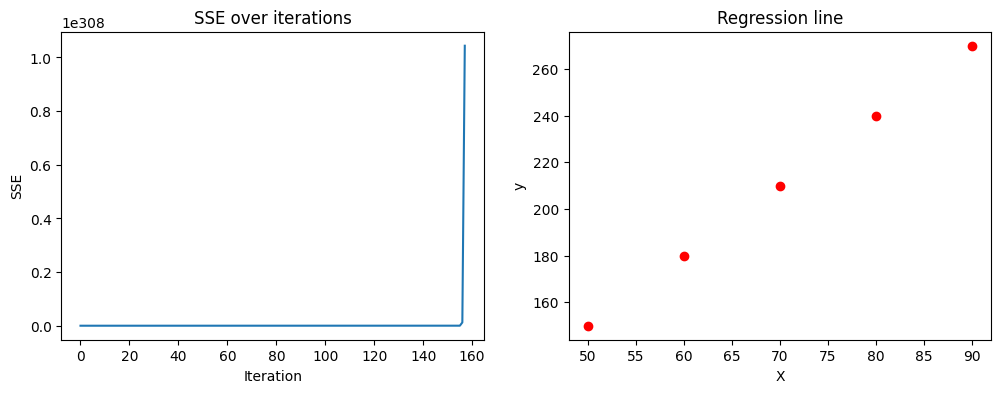

In [5]:
model.plot_training(x, y)

## تاثير الـ Learning Rate

| Learning Rate | النتيجة |
|---|---|
| كبيرة (0.1) | النموذج بيتذبذب او ما بيتقارب |
| صغيرة (0.00001) | النموذج بيتعلم ببطء شديد |
| مناسبة (0.001) | تقارب سريع ومستقر |

C:\Users\DELL\AppData\Local\Temp\ipykernel_4652\255610371.py:27: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)


Big LR   - theta_1: -2.007459532378114e+301
Small LR - theta_1: 2.9993713328364127


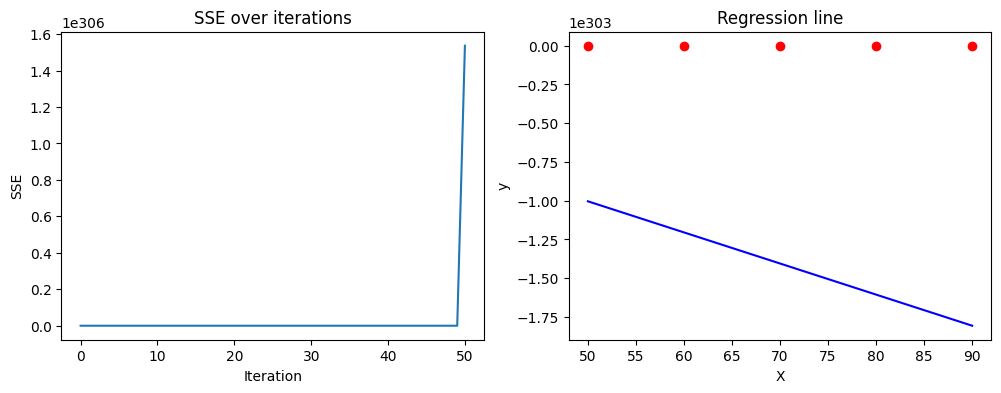

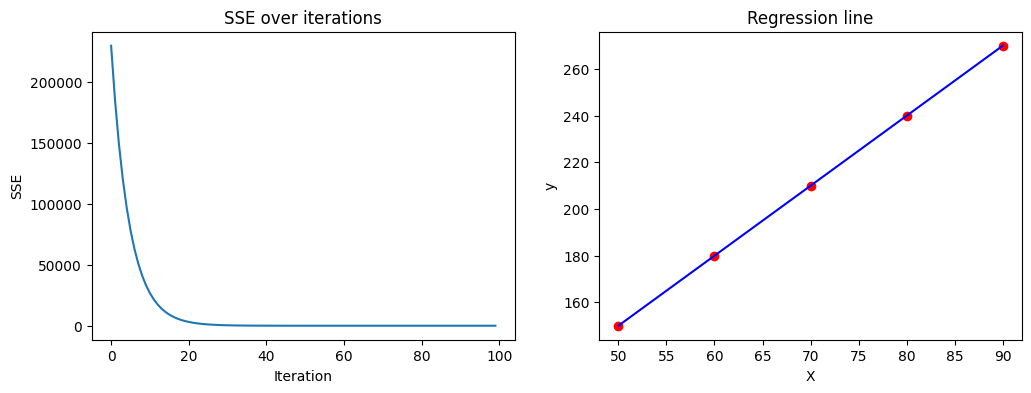

In [6]:
model_big = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_big.fit(x, y)

model_small = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_small.fit(x, y)

print("Big LR   - theta_1:", model_big.theta_1)
print("Small LR - theta_1:", model_small.theta_1)

model_big.plot_training(x, y)
model_small.plot_training(x, y)

## Bonus: MSE (Mean Squared Error)

```
MSE = (1/n) * sum((y - y_pred)^2)
```
كلما كان الـ MSE اصغر، النموذج ادق.

In [7]:
print(f"MSE (lr=0.001):   {model.mse(x, y):.4f}")
print(f"MSE (lr=0.1):     {model_big.mse(x, y):.4f}")
print(f"MSE (lr=0.00001): {model_small.mse(x, y):.4f}")

MSE (lr=0.001):   nan
MSE (lr=0.1):     inf
MSE (lr=0.00001): 0.0001


C:\Users\DELL\AppData\Local\Temp\ipykernel_4652\255610371.py:56: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_pred) ** 2)


## Normalization — ليه مهمة؟

**Normalization (Z-score)** بتحول البيانات لمتوسط 0 وانحراف معياري 1:
```
x_norm = (x - mean(x)) / std(x)
```

لو الـ features مختلفة في الـ scale، الـ gradient descent بياخد وقت اطول للتقارب.
الـ Normalization بتسرع التعلم وبتحسن الاستقرار.

In [8]:
def normalize(X):
    """Z-score normalization"""
    return (X - np.mean(X)) / np.std(X)

In [9]:
x_norm = normalize(x)

model_raw = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_raw.fit(x, y)

model_norm = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model_norm.fit(x_norm, y)

print("Raw  - theta_1:", model_raw.theta_1,  "| MSE:", model_raw.mse(x, y))
print("Norm - theta_1:", model_norm.theta_1, "| MSE:", model_norm.mse(x_norm, y))

Raw  - theta_1: 2.9993713328364127 | MSE: 8.712014832720324e-05
Norm - theta_1: 0.08476886431297276 | MSE: 45716.76488219419


In [10]:
print(f"MSE (raw):        {model_raw.mse(x, y):.4f}")
print(f"MSE (normalized): {model_norm.mse(x_norm, y):.4f}")

MSE (raw):        0.0001
MSE (normalized): 45716.7649


## Multiple Linear Regression

لما يكون عندنا اكتر من feature واحدة:
```
y = theta_0 + theta_1*x1 + theta_2*x2 + ...
```

بصيغة matrix:
```
y_pred = X_b @ theta
gradient = (2/n) * X_b.T @ (y_pred - y)
theta = theta - lr * gradient
```
حيث `X_b` هي `X` مع عمود من الـ 1 (للـ bias).

In [11]:
class LinearRegressionGD_Multi:
    """
    Multiple Linear Regression using Gradient Descent
    يدعم اي عدد من الـ features باستخدام matrix operations
    """
    def __init__(self, learning_rate=0.01, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.sse_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # اضافة عمود الـ ones للـ bias (theta_0)
        X_b = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1)

        for _ in range(self.n_iters):
            y_pred = X_b @ self.theta
            gradient = (2/n_samples) * X_b.T @ (y_pred - y)
            self.theta -= self.lr * gradient

            sse = np.sum((y - y_pred) ** 2)
            self.sse_history.append(sse)

    def predict(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.theta

    def mse(self, X, y):
        return np.mean((y - self.predict(X)) ** 2)

    def plot_training(self):
        plt.plot(self.sse_history)
        plt.title('SSE over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('SSE')
        plt.show()

Predicted price: 7169.50
Theta: [ 76.69542041 102.59985384 -44.59194457]
MSE: 17.11518899253598


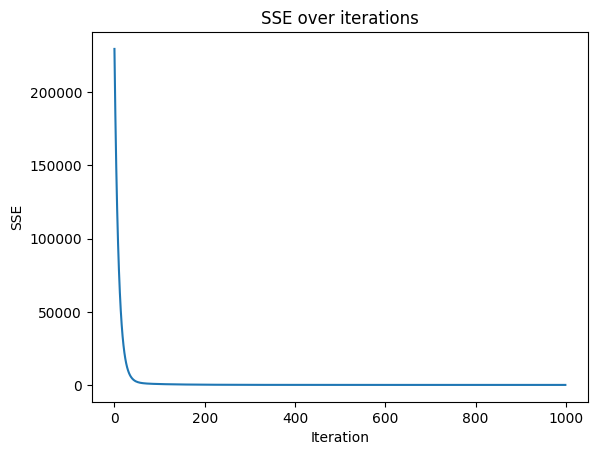

In [12]:
X_multi = np.array([
    [50, 10],
    [60, 20],
    [70, 20],
    [80, 30],
    [90, 30]
])
y = np.array([150, 180, 210, 240, 270])

X_multi_norm = normalize(X_multi)

model_multi = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000)
model_multi.fit(X_multi_norm, y)

pred = model_multi.predict(np.array([[70, 2]]))
print(f"Predicted price: {pred[0]:.2f}")
print("Theta:", model_multi.theta)
print("MSE:", model_multi.mse(X_multi_norm, y))

model_multi.plot_training()

---
## Regularization — Lasso & Ridge

### المشكلة: Overfitting
احيانا النموذج بيتعلم البيانات **كويس جدا** لدرجة انه ما بيتعمم على بيانات جديدة.
الـ **Regularization** بيحل المشكلة دي بانه بيعاقب المعاملات الكبيرة.

### المقارنة:

| | Linear Regression | Ridge (L2) | Lasso (L1) |
|---|---|---|---|
| **دالة الخطا** | SSE | SSE + alpha * sum(theta^2) | SSE + alpha * sum(|theta|) |
| **تاثير على الـ weights** | لا شيء | بتصغّرهم | بتصغّرهم وممكن تعملهم صفر |
| **Feature Selection** | No | No | Yes |

**alpha (lambda)** = قوة الـ regularization:
- alpha صغيرة = تاثير خفيف
- alpha كبيرة = معاملات اصغر (ممكن underfitting)

### Ridge Regression (L2)

بتضيف مربع المعاملات للـ loss:
```
Loss = SSE + alpha * sum(theta_i^2)    (ما بنحسبش theta_0)
```

الـ gradient:
```
gradient = (2/n) * X_b.T @ (y_pred - y) + 2*alpha*theta
```

In [13]:
class RidgeRegressionGD:
    """
    Ridge Regression (L2 Regularization)
    بتضيف alpha * sum(theta^2) للـ loss لتقليل الـ overfitting
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, alpha=1.0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha       # قوة الـ regularization
        self.theta = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_b = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1)

        for _ in range(self.n_iters):
            y_pred = X_b @ self.theta

            # gradient الـ MSE
            gradient = (2 / n_samples) * X_b.T @ (y_pred - y)

            # اضافة L2 regularization (ما بنعاقبش theta_0)
            reg_term = np.zeros_like(self.theta)
            reg_term[1:] = 2 * self.alpha * self.theta[1:]
            gradient += reg_term

            self.theta -= self.lr * gradient

            # Ridge loss = SSE + penalty
            sse = np.sum((y - y_pred) ** 2)
            ridge_penalty = self.alpha * np.sum(self.theta[1:] ** 2)
            self.loss_history.append(sse + ridge_penalty)

    def predict(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.theta

    def mse(self, X, y):
        return np.mean((y - self.predict(X)) ** 2)

    def plot_training(self):
        plt.plot(self.loss_history, color='green')
        plt.title(f'Ridge Loss (alpha={self.alpha}) over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Ridge Loss')
        plt.show()

### Lasso Regression (L1)

بتضيف القيمة المطلقة للمعاملات:
```
Loss = SSE + alpha * sum(|theta_i|)
```

الـ gradient مش smooth، فبنستخدم **sign function**:
```
gradient += alpha * sign(theta)
```

**الميزة الكبيرة**: Lasso ممكن تعمل بعض الـ weights **= صفر تماما** = Feature Selection تلقائي!

In [14]:
class LassoRegressionGD:
    """
    Lasso Regression (L1 Regularization)
    بتضيف alpha * sum(|theta|) للـ loss — بتعمل Feature Selection تلقائيا
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, alpha=1.0):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.theta = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_b = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1)

        for _ in range(self.n_iters):
            y_pred = X_b @ self.theta

            # gradient الـ MSE
            gradient = (2 / n_samples) * X_b.T @ (y_pred - y)

            # اضافة L1 regularization باستخدام sign function
            reg_term = np.zeros_like(self.theta)
            reg_term[1:] = self.alpha * np.sign(self.theta[1:])
            gradient += reg_term

            self.theta -= self.lr * gradient

            # Lasso loss = SSE + penalty
            sse = np.sum((y - y_pred) ** 2)
            lasso_penalty = self.alpha * np.sum(np.abs(self.theta[1:]))
            self.loss_history.append(sse + lasso_penalty)

    def predict(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.theta

    def mse(self, X, y):
        return np.mean((y - self.predict(X)) ** 2)

    def plot_training(self):
        plt.plot(self.loss_history, color='orange')
        plt.title(f'Lasso Loss (alpha={self.alpha}) over iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Lasso Loss')
        plt.show()

## مقارنة بين الثلاثة نماذج

In [15]:
X_norm = normalize(X_multi)

# تدريب الثلاثة نماذج
model_linear = LinearRegressionGD_Multi(learning_rate=0.01, n_iters=1000)
model_linear.fit(X_norm, y)

model_ridge = RidgeRegressionGD(learning_rate=0.01, n_iters=1000, alpha=0.1)
model_ridge.fit(X_norm, y)

model_lasso = LassoRegressionGD(learning_rate=0.01, n_iters=1000, alpha=0.1)
model_lasso.fit(X_norm, y)

print("=" * 55)
print(f"{'Model':<18} {'Weights (theta)':<25} MSE")
print("=" * 55)
print(f"Linear          {str(np.round(model_linear.theta, 3)):<25} {model_linear.mse(X_norm, y):.4f}")
print(f"Ridge (L2)      {str(np.round(model_ridge.theta, 3)):<25} {model_ridge.mse(X_norm, y):.4f}")
print(f"Lasso (L1)      {str(np.round(model_lasso.theta, 3)):<25} {model_lasso.mse(X_norm, y):.4f}")
print("=" * 55)
print("\nلاحظ ان Ridge و Lasso weights اصغر من Linear!")
print("وان Lasso ممكن تعمل بعض الـ weights = 0 تماما")

Model              Weights (theta)           MSE
Linear          [ 76.695 102.6   -44.592] 17.1152
Ridge (L2)      [136.087  69.463  -9.984] 70.0677
Lasso (L1)      [ 77.328 102.332 -44.126] 16.7605

لاحظ ان Ridge و Lasso weights اصغر من Linear!
وان Lasso ممكن تعمل بعض الـ weights = 0 تماما


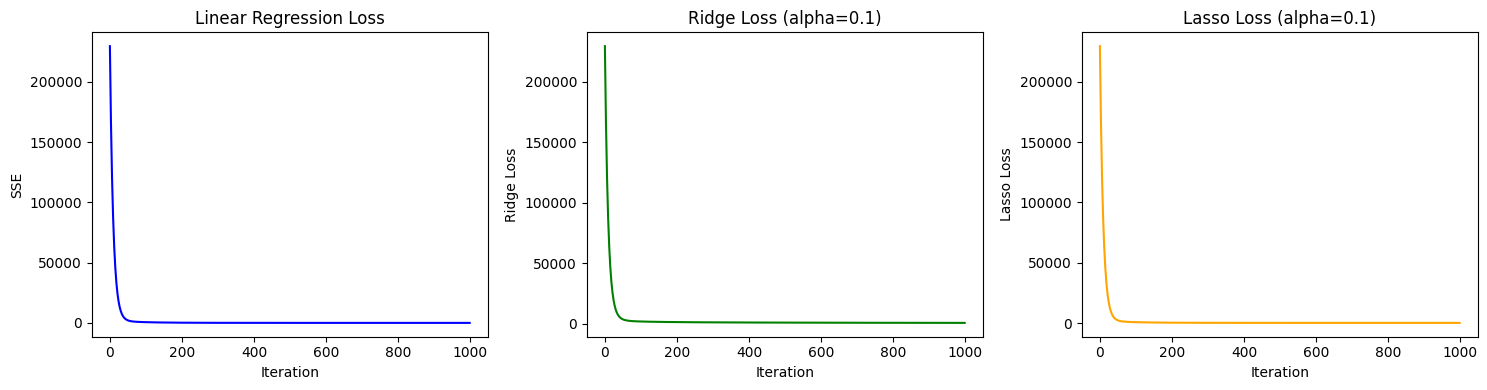

In [16]:
# رسم منحنيات الـ loss للثلاثة نماذج
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(model_linear.sse_history, color='blue')
plt.title('Linear Regression Loss')
plt.xlabel('Iteration'); plt.ylabel('SSE')

plt.subplot(1, 3, 2)
plt.plot(model_ridge.loss_history, color='green')
plt.title(f'Ridge Loss (alpha={model_ridge.alpha})')
plt.xlabel('Iteration'); plt.ylabel('Ridge Loss')

plt.subplot(1, 3, 3)
plt.plot(model_lasso.loss_history, color='orange')
plt.title(f'Lasso Loss (alpha={model_lasso.alpha})')
plt.xlabel('Iteration'); plt.ylabel('Lasso Loss')

plt.tight_layout()
plt.show()

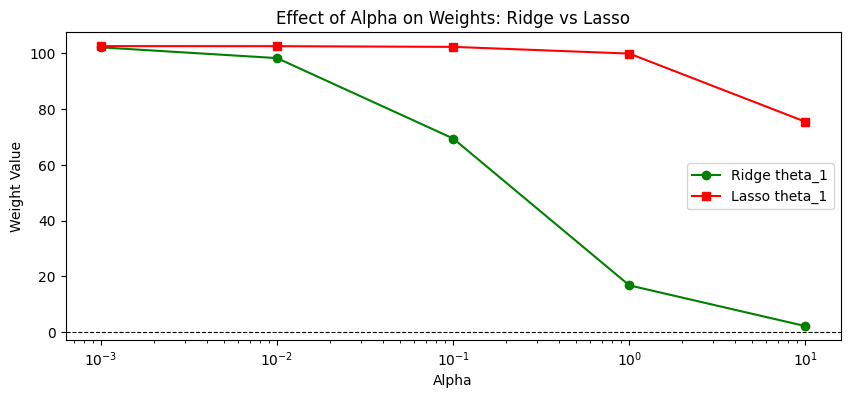

لاحظ ان Lasso بتقرب الـ weights من الصفر اسرع من Ridge!


In [17]:
# تاثير alpha على الـ weights في Ridge و Lasso
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

ridge_weights = []
lasso_weights = []

for a in alphas:
    r = RidgeRegressionGD(learning_rate=0.01, n_iters=1000, alpha=a)
    r.fit(X_norm, y)
    ridge_weights.append(r.theta[1])

    l = LassoRegressionGD(learning_rate=0.01, n_iters=1000, alpha=a)
    l.fit(X_norm, y)
    lasso_weights.append(l.theta[1])

plt.figure(figsize=(10, 4))
plt.plot(alphas, ridge_weights, 'g-o', label='Ridge theta_1')
plt.plot(alphas, lasso_weights, 'r-s', label='Lasso theta_1')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Weight Value')
plt.title('Effect of Alpha on Weights: Ridge vs Lasso')
plt.legend()
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

print("لاحظ ان Lasso بتقرب الـ weights من الصفر اسرع من Ridge!")

---
## ملخص النوتبوك

1. **LinearRegressionGD** — Linear Regression بمتغير واحد باستخدام Gradient Descent
2. **Learning Rate** — كبيرة = تذبذب، صغيرة = بطء، مناسبة = تقارب سليم
3. **MSE** — مقياس دقة النموذج، كلما صغر كان افضل
4. **Normalization** — بتسرع التعلم وتحسن الاستقرار
5. **LinearRegressionGD_Multi** — Multi-feature regression باستخدام matrix operations
6. **Ridge (L2)** — تضيف `alpha * sum(theta^2)` للـ loss، بتصغّر الـ weights
7. **Lasso (L1)** — تضيف `alpha * sum(|theta|)` للـ loss، ممكن تعمل weights = 0 (Feature Selection)